In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

#### Creating data.

In [28]:
import pandas as pd
import numpy as np

np.random.seed(42)

data = {
    'Age': np.random.randint(21, 60, 10000).astype(float),
    'Gender': np.random.choice(['Male', 'Female'], 10000),
    'Education': np.random.choice(['BCA', 'BTech', 'BBA'], 10000),
    'Salary': np.random.randint(15000, 150000, 10000).astype(float),
    'CIBIL_Score': np.random.randint(300, 900, 10000),
    'Loan_Status': np.random.choice([0, 1], 10000)
}

df = pd.DataFrame(data)

# giving null values to age  & salary column.
df.loc[10:30, 'Age'] = np.nan
df.loc[40:60, 'Salary'] = np.nan

print(df.head(15))

     Age  Gender Education    Salary  CIBIL_Score  Loan_Status
0   59.0  Female       BBA   95221.0          370            1
1   49.0    Male       BCA   86121.0          740            0
2   35.0  Female       BCA   89090.0          438            1
3   28.0  Female       BBA  124777.0          401            0
4   41.0    Male       BCA   16634.0          767            0
5   59.0    Male       BCA   31908.0          582            1
6   39.0    Male     BTech   95653.0          328            0
7   43.0  Female       BBA   82258.0          317            1
8   31.0    Male       BCA   84400.0          807            0
9   31.0    Male       BBA  131107.0          319            0
10   NaN  Female     BTech  144468.0          625            1
11   NaN    Male       BBA  127436.0          655            1
12   NaN  Female       BBA   46131.0          732            0
13   NaN  Female       BBA   76760.0          698            1
14   NaN    Male     BTech   82370.0          317      

In [29]:
df.info()  # data checking

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          9979 non-null   float64
 1   Gender       10000 non-null  str    
 2   Education    10000 non-null  str    
 3   Salary       9979 non-null   float64
 4   CIBIL_Score  10000 non-null  int32  
 5   Loan_Status  10000 non-null  int64  
dtypes: float64(2), int32(1), int64(1), str(2)
memory usage: 429.8 KB


In [30]:
df.isnull().sum() # finding null values in data

Age            21
Gender          0
Education       0
Salary         21
CIBIL_Score     0
Loan_Status     0
dtype: int64

### Filling Age and Salary nan with median value.

In [31]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [32]:
df['Salary'] = df['Salary'].fillna(df['Salary'].median())

In [33]:
df.isnull().sum()  # checking for null values after imputation

Age            0
Gender         0
Education      0
Salary         0
CIBIL_Score    0
Loan_Status    0
dtype: int64

### Encoding data for ML model.

In [34]:
df['Education'].unique() # finding unique values in education column.

<StringArray>
['BBA', 'BCA', 'BTech']
Length: 3, dtype: str

In [35]:
df_encoded = pd.get_dummies(df, columns=['Gender','Education'], drop_first=True, dtype=int) # encoded the values of gender &  education by one-hot-encoder.

In [53]:
df_encoded.head()

,Age,Salary,CIBIL_Score,Loan_Status,Gender_Male,Education_BCA,Education_BTech
0,59.0,95221.0,370,1,0,0,0
1,49.0,86121.0,740,0,1,1,0
2,35.0,89090.0,438,1,0,1,0
3,28.0,124777.0,401,0,0,0,0
4,41.0,16634.0,767,0,1,1,0


In [55]:
df_encoded['Loan_Status'] = np.where((df_encoded['Salary'] > 40000)& (df_encoded['CIBIL_Score']>650),1,0)

In [56]:
X = df_encoded[['Age', 'Salary','CIBIL_Score','Gender_Male','Education_BCA','Education_BTech']]
y = df_encoded['Loan_Status']

In [57]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state = 42)

In [41]:
scaler = MinMaxScaler()

In [58]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [43]:
model = LogisticRegression()  # model defining in variable.

In [59]:
model.fit(X_train_scaled,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [60]:
prediction = model.predict(X_test_scaled)
prediction

array([0, 1, 0, ..., 1, 0, 0], shape=(2000,))

In [61]:
score = accuracy_score(y_test,prediction)
print(score * 100)

89.1


In [62]:
cf = confusion_matrix(y_test,prediction)
cf

array([[1181,  104],
       [ 114,  601]])

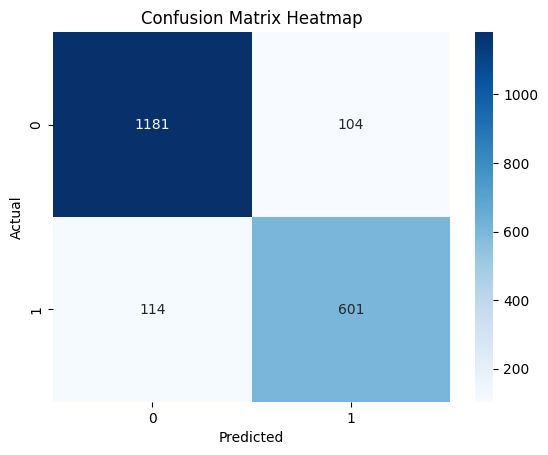

In [63]:
sns.heatmap(cf,annot=True,fmt='d',cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.show()

In [50]:
report = classification_report(y_test,prediction)
print(report)

              precision    recall  f1-score   support

           0       0.51      0.72      0.59      1016
           1       0.49      0.28      0.35       984

    accuracy                           0.50      2000
   macro avg       0.50      0.50      0.47      2000
weighted avg       0.50      0.50      0.48      2000



### Inserting new customer data.

In [71]:
new_cus = np.array([[30,80000,720,1,0,1]])

In [72]:
new_cus_scaled = scaler.transform(new_cus)

c:\Users\uttam\OneDrive\Desktop\ML_Journey\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [73]:
prediction = model.predict(new_cus_scaled)
prediction

array([1])